In [1]:
import pandas as pd

In [2]:
metrics_v1_df = pd.read_csv("results/v1/topics_20230101_to_20230430_bertopic_v1_run_metrics.csv")
metrics_v2_df = pd.read_csv("results/v2/topics_20230101_to_20230430_bertopic_v2_run_metrics.csv")
metrics_online_df = pd.read_csv("results/online/topics_20230101_to_20230430_bertopic_online_run_metrics.csv")
metrics_v1_ab_df = pd.read_csv("results/ab/bertopic_v1_topics_globo_run_metrics.csv")
metrics_v2_ab_df = pd.read_csv("results/ab/bertopic_v2_topics_globo_run_metrics.csv")
metrics_online_ab_df = pd.read_csv("results/ab/bertopic_online_topics_globo_run_metrics.csv")

In [3]:
columns = ['num_topics', 'doc_count', 'num_unassigned', 'npmi', 'cv', 'td']
metrics = ["max", "min", "mean", "std"]
metrics_v1 = metrics_v1_df[columns].agg(metrics)
metrics_v2 = metrics_v2_df[columns].agg(metrics)
metrics_online = metrics_online_df[columns].agg(metrics)
metrics_v1_ab = metrics_v1_ab_df[columns].agg(metrics)
metrics_v2_ab = metrics_v2_ab_df[columns].agg(metrics)
metrics_online_ab = metrics_online_ab_df[columns].agg(metrics)

In [4]:
print("\nMetrics v1 NPR:")
print(metrics_v1)
print("\nMetrics v2 NPR:")
print(metrics_v2)
print("\nMetrics Online NPR:")
print(metrics_online)
print("\nMetrics v1 AB:")
print(metrics_v1_ab)
print("\nMetrics v2 AB:")
print(metrics_v2_ab)
print("\nMetrics Online AB:")
print(metrics_online_ab)


Metrics v1 NPR:
      num_topics   doc_count  num_unassigned      npmi        cv        td
max    18.000000  900.000000      358.000000  0.128069  0.668555  1.000000
min     2.000000  276.000000        0.000000 -0.245439  0.220338  0.880000
mean    6.675000  674.000000      121.316667 -0.084153  0.425330  0.959374
std     4.589287  176.034708      110.014360  0.083919  0.079278  0.031300

Metrics v2 NPR:
      num_topics   doc_count  num_unassigned      npmi        cv        td
max    37.000000  900.000000      120.000000 -0.164125  0.460396  1.000000
min     4.000000  276.000000        0.000000 -0.356676  0.312373  0.933333
mean   22.650000  674.000000       52.491667 -0.282165  0.399090  0.983452
std     7.780227  176.034708       28.451343  0.039072  0.022716  0.011610

Metrics Online NPR:
      num_topics   doc_count  num_unassigned      npmi        cv        td
max         15.0  900.000000             0.0 -0.279825  0.475409  0.793333
min         15.0  276.000000             0.0 

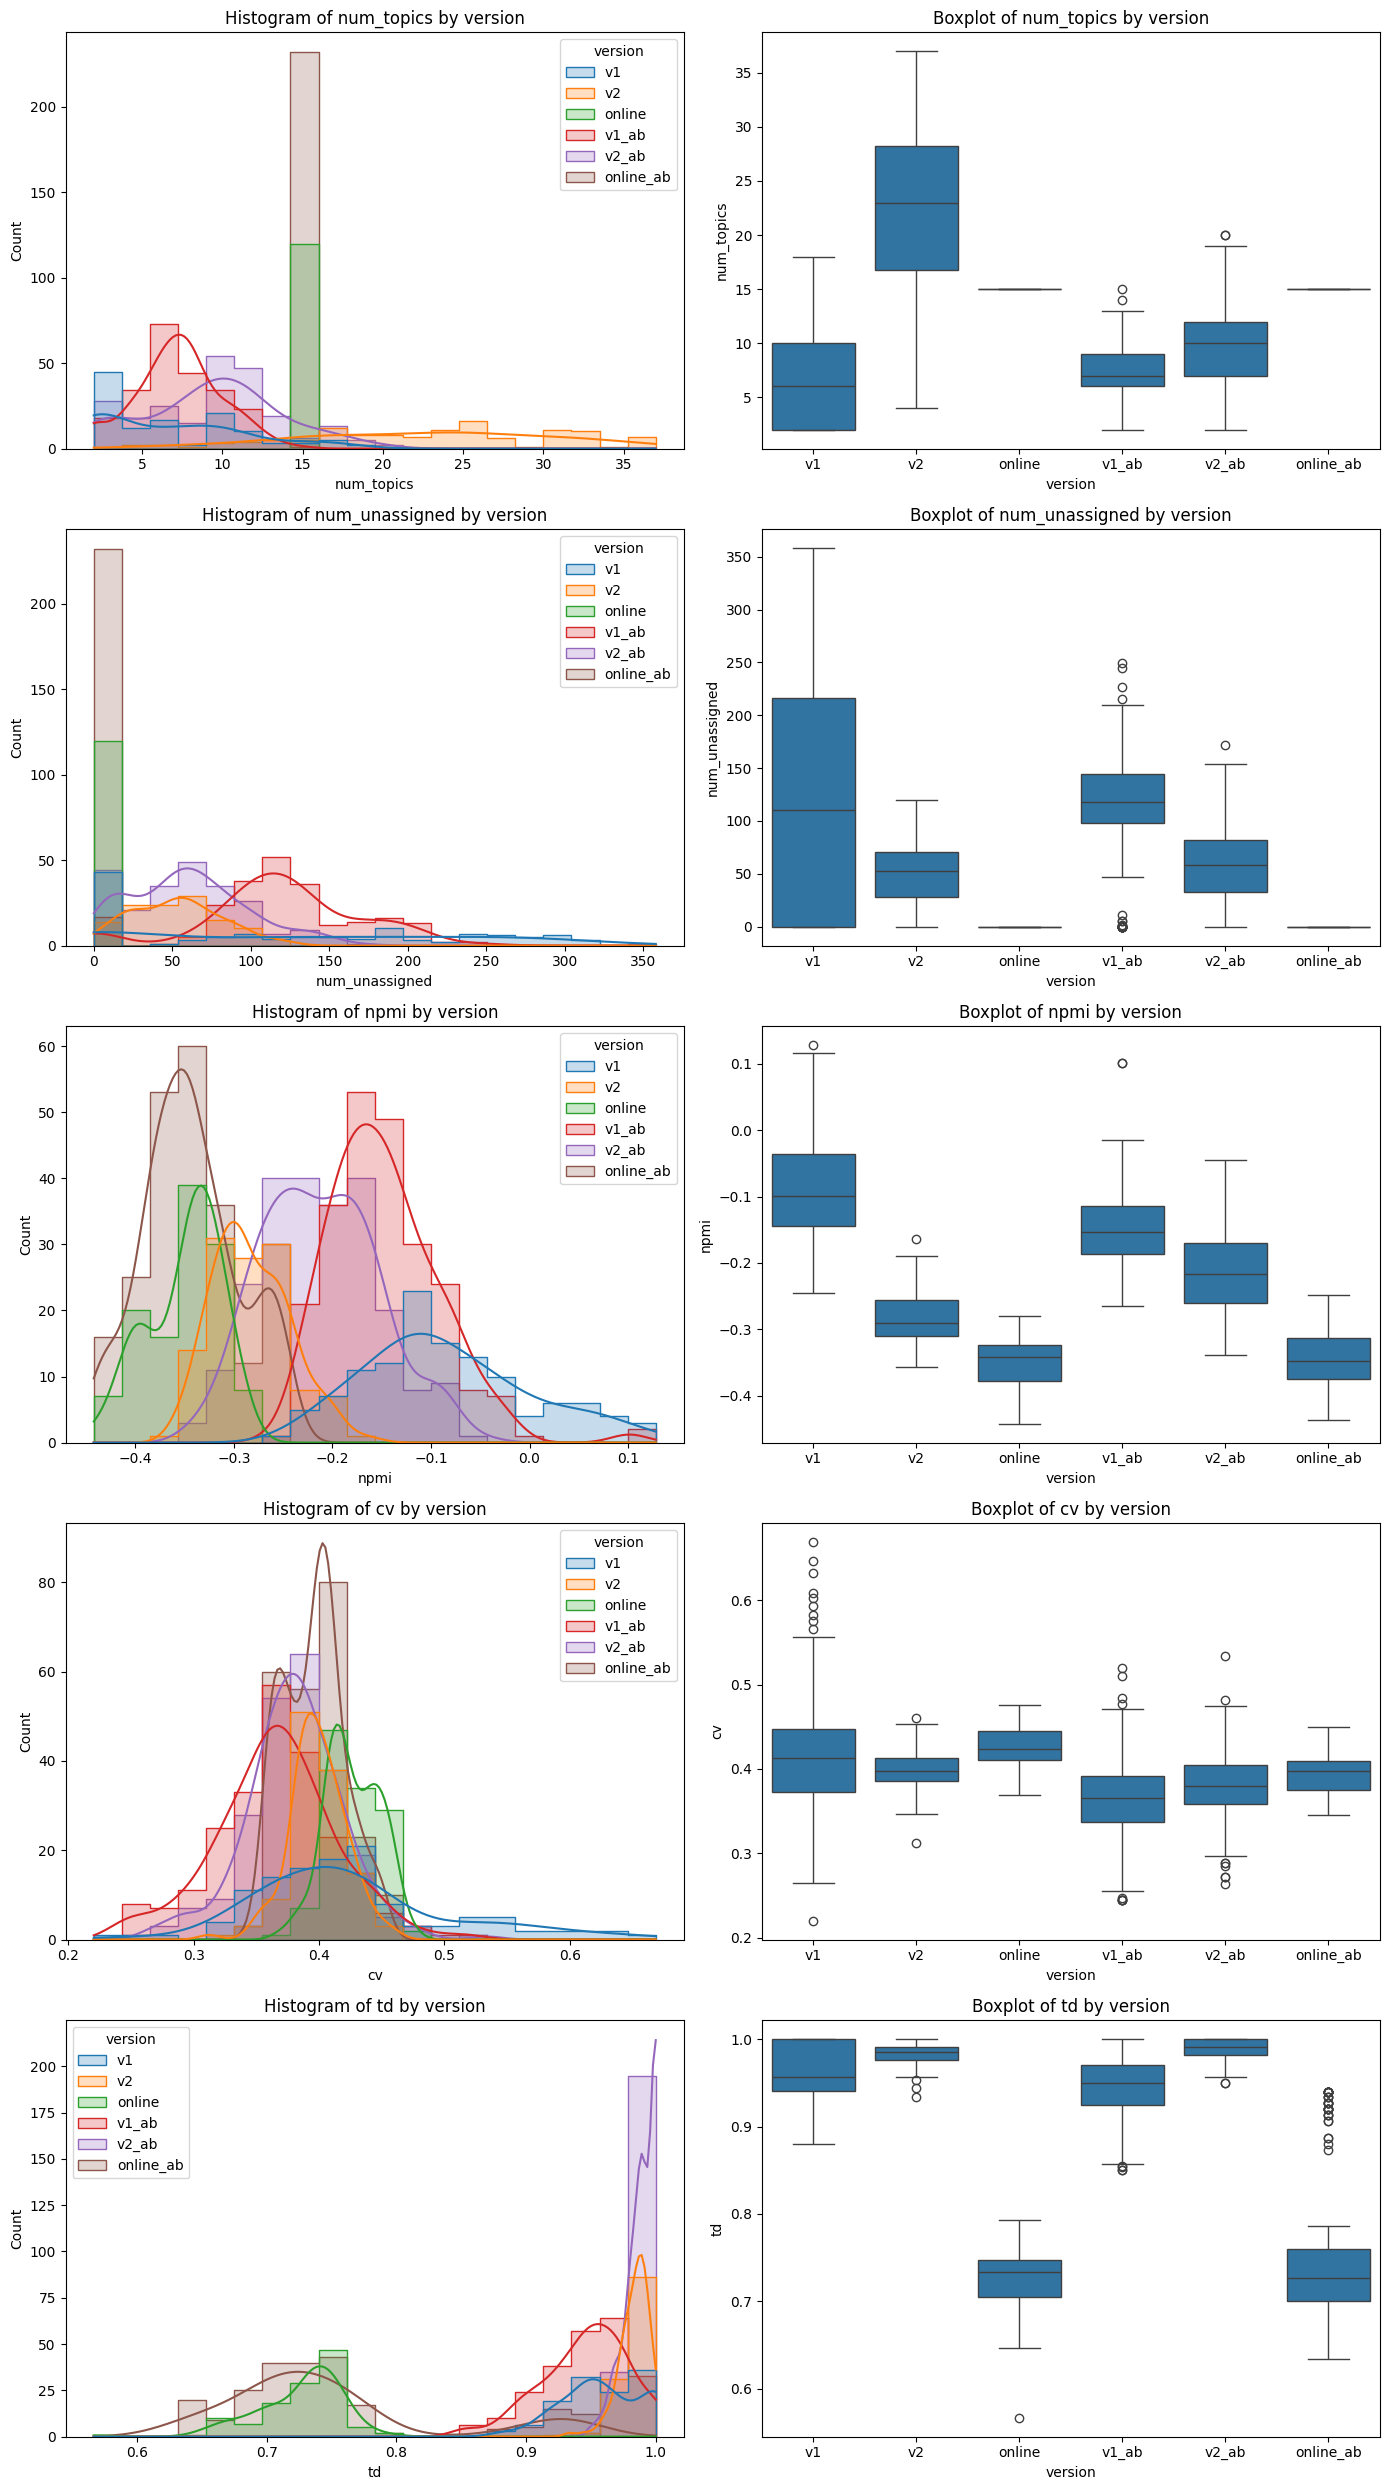

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.concat([
    metrics_v1_df.assign(version='v1'),
    metrics_v2_df.assign(version='v2'),
    metrics_online_df.assign(version='online'),
    metrics_v1_ab_df.assign(version='v1_ab'),
    metrics_v2_ab_df.assign(version='v2_ab'),
    metrics_online_ab_df.assign(version='online_ab')
])

metrics = ['num_topics', 'num_unassigned', 'npmi', 'cv', 'td']
fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 5 * len(metrics)))

for i, metric in enumerate(metrics):
    sns.histplot(data=df, x=metric, hue='version', ax=axes[i, 0], kde=True, bins=20, element="step")
    axes[i, 0].set_title(f'Histogram of {metric} by version')

    sns.boxplot(data=df, x='version', y=metric, ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {metric} by version')

plt.tight_layout()
plt.show()